# **Project: Amazon Product Recommendation System**


Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its very good selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

The main objective of this project is to build a recommendation system to recommend products to customers based on their previous ratings for other products. From the collection of labeled data of Amazon reviews of products, we will extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

Let's start by mounting the Google drive on Colab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Installing surprise library**

In [2]:
!pip install surprise

In [3]:
!pip install numpy==1.26.0

## **Importing the necessary libraries and overview of the dataset**

In [4]:
# Basic python libraries
import numpy as np
import pandas as pd

# Python libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD
from collections import defaultdict

# For implementing cross validation
from surprise.model_selection import KFold

import warnings
warnings.filterwarnings('ignore')

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [5]:
Path = '/content/drive/MyDrive/Colab Notebooks/Python for Data Science/Amazon Product Recommendation System Project/ratings_Electronics.csv'
DataSet = pd.read_csv(Path, header = None)
DataSet.columns = ['user_id', 'prod_id', 'rating', 'timestamp']

In [6]:
DataSet.head()

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [7]:
DataSet.drop('timestamp', axis = 1, inplace = True)
df = DataSet.copy()

In [8]:
df.sample(3)

,user_id,prod_id,rating
3927653,A1RY5W23HYS0FY,B0047DS41S,4.0
5360022,AYFQ5UT29R7U5,B006CQR7CK,3.0
1686611,A27DMUBAVWKU00,B0014KY82G,2.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   user_id  object 
 1   prod_id  object 
 2   rating   float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


As this dataset is very large and has 7,824,482 observations, training and evaluating recommendation models on the full data is computationally heavy. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [10]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [11]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [12]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [13]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[~ df.prod_id.isin(remove_users)]

In [14]:
# Print a few rows of the imported dataset
df.head()

,user_id,prod_id,rating
1310,A3LDPF5FMB782Z,1400501466,5.0
1322,A1A5KUIIIHFF4U,1400501466,1.0
1335,A2XIOXRRYX0KZY,1400501466,3.0
1451,AW3LX47IHPFRL,1400501466,5.0
1456,A1E3OB6QMBKRYZ,1400501466,1.0


## **Exploratory Data Analysis**

In [15]:
# Check the number of rows and columns
df.shape

(65290, 3)

> df_final has `65290` rows and `3` columns.

In [16]:
# Check Data types
df.dtypes

,0
user_id,object
prod_id,object
rating,float64


> Both user_id and prod_id are of datatype object, while rating is of numeric data type.

In [17]:
# Check for missing values present
df.isna().sum()

,0
user_id,0
prod_id,0
rating,0


> There are no missing values present in df_final.



In [18]:
# Summary statistics of 'rating' variable
df.describe()

,rating
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


- There are `65290` rows, which aligns with our earlier observation.
- Ratings are concentrated at the high end: the mean rating is `~4.29` and the median is `5`, with relatively low spread (`std ~0.99`). This indicates a strong positive skew (many `5` ratings), so the distribution is not symmetric.




### **Rating distribution**

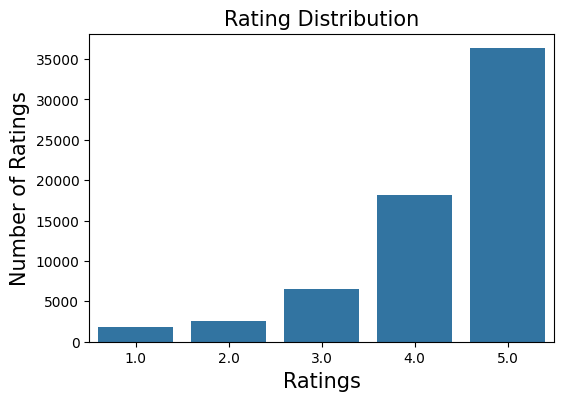

In [19]:
# Create the bar plot
plt.figure(figsize = (6, 4))
sns.countplot(x = 'rating', data = df)

plt.title('Rating Distribution', fontsize = 15)
plt.xlabel('Ratings', fontsize = 15)
plt.ylabel('Number of Ratings', fontsize = 15)
plt.show()

The bar plot reinforces the statistical patterns observed earlier in the summary statistics:
  - The ratings '`5`' dominate the dataset

There are very few '`1`' rating

The rating distribution is not symmetric: the ratings are concentrated near upper bound, hence right-censored.

### **Unique users and items in the dataset**

In [20]:
# Number of total rows in the data and number of unique user id and product id in the data
df.shape[0], df.user_id.nunique(), df.prod_id.nunique()

(65290, 1540, 5689)

The dataset contains `65290` rows, with `1540` unique users and `5689` unique products.

### **Users with the most number of ratings**

In [21]:
# Top 10 users based on the number of ratings
df.user_id.value_counts().head(10)

,count
user_id,
ADLVFFE4VBT8,295
A3OXHLG6DIBRW8,230
A1ODOGXEYECQQ8,217
A36K2N527TXXJN,212
A25C2M3QF9G7OQ,203
A680RUE1FDO8B,196
A1UQBFCERIP7VJ,193
A22CW0ZHY3NJH8,193
AWPODHOB4GFWL,184


user_id `ADLVFFE4VBT8` has the most ratings: `295`.

There is a noticeable variation in the number of ratings even for the top `10` users (based on their rating counts), ranging from `179` to `295`.

A small subset of users contribute a disproportionately high share of intercations, with only `5` out of the `1540` users giving more than `200` ratings.
This suggests user rating

**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [22]:
df.sample()

,user_id,prod_id,rating
3651297,A1RL1OTV8IJMVD,B003XDU2Y0,5.0


In [23]:
# Calculate the average rating for each product
average_rating = df.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
rating_count = df.groupby('prod_id')['rating'].count()

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame(
    {'average_rating': average_rating,
     'rating_count': rating_count}
    )

# Sort the dataframe by average of ratings in the descending order
final_rating.sort_values(by = 'average_rating', ascending = False, inplace = True)

# See the first five records of the "final_rating" dataset
final_rating.head()

,average_rating,rating_count
prod_id,,
B00LGQ6HL8,5.0,5
B003DZJQQI,5.0,14
B005FDXF2C,5.0,7
B00I6CVPVC,5.0,7
B00B9KOCYA,5.0,8


In [24]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions
def top_n_products(data, n, min_interactions):

  # Finding products with minimum number of interactions
  recommendations = data[data['rating_count'] > min_interactions]

  # Sorting values with respect to average rating
  recommendations.sort_values(by = 'average_rating', ascending = False, inplace = True)

  #Return top n products
  return recommendations.index[ :n]



### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [25]:
# Call the top_n_products function
top_5_50 = list(top_n_products(final_rating, 5, 50))
top_5_50

['B001TH7GUU', 'B003ES5ZUU', 'B0019EHU8G', 'B006W8U2MU', 'B000QUUFRW']

### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [26]:
# Call the top_n_items function
top_5_100 = list(top_n_products(final_rating, 5, 100))
top_5_100

['B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B002V88HFE', 'B004CLYEDC']

We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [27]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item whose **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [28]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [29]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale = (1,5))

# Loading the rating dataset
data = Dataset.load_from_df(df[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test datasets
trainset, testset = train_test_split(data, test_size = 0.3, random_state = 1)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [30]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': True}

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
knn_user_algo = KNNBasic(sim_options = sim_options, verbose = False, random_state = 1)

# Fit the model on the training data
knn_user_algo.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(knn_user_algo)

RMSE: 1.0390
Precision:  0.852
Recall:  0.785
F_1 score:  0.817


The baseline user–user KNN achieves `RMSE = 1.039`, with strong `Precision@10 = 0.852` and `Recall@10 = 0.785`.
- This suggests that, when it recommends items above the relevance threshold (`3.5`), most are genuinely relevant to users (high precision), while still recovering a large fraction of relevant items (recall).

The score `f1@10 = 0.817` suggests a balanced trade-off between precision and recall, hence consistent recommendation quality across users.

Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [31]:
# Predicting rating for a sample user with an interacted product
knn_user_algo.predict('A3LDPF5FMB782Z', '1400501466', r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.80   {'actual_k': 5, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.8, details={'actual_k': 5, 'was_impossible': False})

For this user-item pair, the model underestimates the true rating, predicting 3.8 instead of 5, reflecting some prediction error.

Below is the function to find the **list of users who have not seen the product with product id "1400501466"**.

In [75]:
def n_users_not_interacted_with(n, data, prod_id):
    users_interacted_with_product = set(data[data['prod_id'] == prod_id]['user_id'])
    all_users = set(data['user_id'])
    return list(all_users.difference(users_interacted_with_product))[n:n+5] # where n is the number of elements to get in the list

In [77]:
# Find unique user_id where prod_id is not equal to "1400501466"
n_users_not_interacted_with(375, df, '1400501466')

['A1DQHS7MOVYYYA',
 'A3T7V207KRDE2O',
 'A2UOHALGF2X77Q',
 'A3L9E0YI7C5G0W',
 'AUCISQA1YXX86']

* It can be observed from the above list that **user "A2UOHALGF2X77Q" has not seen the product with productId "1400501466"** as this user id is a part of the above list.

**Below we are predicting rating for `userId=A2UOHALGF2X77Q` and `prod_id=1400501466`.**

In [34]:
# Predicting rating for a sample user with a non interacted product
knn_user_algo.predict('A2UOHALGF2X77Q', '1400501466', verbose = True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.34   {'actual_k': 3, 'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.3355875039423895, details={'actual_k': 3, 'was_impossible': False})

- The predicted rating of `4.34` suggests strong expected user preference, indicating that the system would rank this item highly for recommendation (since the relevance threshold is `3.5`).
- The prediction was computed using only  three (`actual_k = 3`) nearest neighbors, which may reduce estimate stability compared to predictions with larger neighborhoods.


### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [35]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [105, 110, 115], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine', 'pearson', 'pearson_baseline'],
                              'user_based': [True]}
              }
# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures = ['rmse', 'mae'], cv = 3, n_jobs = -1)

# Fitting the data
gs.fit(data)

# Best RMSE score
print(gs.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])


0.9719194096174398
{'k': 115, 'min_k': 6, 'sim_options': {'name': 'cosine', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [36]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options = {'name': 'cosine',
               'user_based': True}

# Creating an instance of KNNBasic with optimal hyperparameter values
opt_knn_user_algo = KNNBasic(
    sim_options = sim_options,
    k = 110, min_k = 6,
    verbose = False, random_state = 1
    )

# Training the algorithm on the trainset
opt_knn_user_algo.fit(trainset)

# Let us compute precision@k and recall@k also with k =10
precision_recall_at_k(opt_knn_user_algo)

RMSE: 0.9791
Precision:  0.842
Recall:  0.808
F_1 score:  0.825


After hyperparameter tuning, the user–user collaborative filtering model demonstrated improved overall performance.
- Parameter tuning substantially improved rating prediction accuracy, reducing RMSE from `1.0390` to `0.9791`, indicating more accurate rating prediction.
- Despite the precision@10 decreasing slightly to `0.842`, implying  that the model may recommend a few more borderline items, there is a clear improvement in the recall@10 (`0.808`). Thus, the model retrieves more relevant items.
- There is a slightly higher f1@10 (from `0.817` to `0.825`), suggesting a better balance between relevance and coverage.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [37]:
# Use opt_knn_user_algo model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
opt_knn_user_algo.predict('A3LDPF5FMB782Z', '1400501466', r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.30   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.29674200818327, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

In [38]:
# Use opt_knn_user_algo model to recommend for userId "A2UOHALGF2X77Q" and productId "1400501466"
opt_knn_user_algo.predict('A2UOHALGF2X77Q', '1400501466', verbose = True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.30   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.29674200818327, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

For these specific user–item predictions, the tuned user–user model returns `was_impossible=True` due to insufficient overlap in the neighborhood (Not enough neighbors).

In this case, Surprise falls back to a non-personalized estimate close to the global mean (`~4.3`) rather than a similarity-weighted prediction.

So, while tuning improved aggregate metrics overall, user–user CF can still fail to personalize for some (user, item) pairs when co-rating overlap is sparse, and especially with stricter `min_k` requirements.

### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [39]:
# 0 is the inner id of the above user
opt_knn_user_algo.get_neighbors(0, k = 5)

[1, 10, 17, 18, 28]

In [40]:
trainset.to_raw_uid(0)

'A2EN82VBJT44QP'

In [41]:
neighbors = opt_knn_user_algo.get_neighbors(0, k = 5)

for neighbor in neighbors:
    print(trainset.to_raw_uid(neighbor))

A3NEAETOSXDBOM
A225G2TFM76GYX
AOWF9T81XMX2S
AR18DH5SL9F73
A39137LW12KK7B


### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [42]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [43]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
recommendations = get_recommendations(df, 'A3LDPF5FMB782Z', 5, opt_knn_user_algo)

In [44]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations, columns = ['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,B002WE4HE2,5.000000
1,B002WE6D44,5.000000
2,B0052SCU8U,5.000000
3,B003ES5ZUU,4.951627
4,B000Q8UAWY,4.857143


### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [45]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': False}

# KNN algorithm is used to find desired similar items. Use random_state=1
knn_item_algo = KNNBasic(sim_options = sim_options, verbose = False, random_state = 1)

# Train the algorithm on the trainset, and predict ratings for the test set
knn_item_algo.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(knn_item_algo)

RMSE: 1.0345
Precision:  0.833
Recall:  0.768
F_1 score:  0.799


- The baseline item–item KNN performs slightly worse than the tuned user–user model on this dataset (`RMSE = 1.0345 vs 0.9791`). - Its `Precision@10 = 0.833` and `Recall@10 = 0.768` indicate decent ranking quality, but it retrieves fewer relevant items and recommends slightly more non-relevant items among the top 10, than the tuned user–user approach.
- Overall ranking performance is also slightly inferior, with `f1@10 = 0.799`.

Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [46]:
# Predicting rating for a sample user with an interacted product
knn_item_algo.predict('A3LDPF5FMB782Z', '1400501466', r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.19   {'actual_k': 16, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.1875, details={'actual_k': 16, 'was_impossible': False})

For user `A3LDPF5FMB782Z` and item `1400501466`, the item–item collaborative filtering model predicted a rating of `4.19` compared to the true rating of `5`. The prediction was computed using `16` similar items (`actual_k = 16`), indicating strong item co-rating structure.
-  This is a meaningful improvement compared to the baseline user-user model's estimate of `3.8`, and the tuned user-user model's non-personalized estimate of `4.3`,

Below we are **predicting rating for the `userId = A2UOHALGF2X77Q` and `prod_id = 1400501466`**.

In [47]:
# Predicting rating for a sample user with a non interacted product
knn_item_algo.predict('A2UOHALGF2X77Q', '1400501466', verbose = True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.67   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.666666666666667, details={'actual_k': 6, 'was_impossible': False})

For user `A2UOHALGF2X77Q` and item `1400501466`, the item–item similarity model predicted a rating of `4.67` despite no prior interaction. The prediction was computed using six similar items (`actual_k = 6`).

- This is higher that the predicted rating of `4.34` from the baseline user-user model, using `3` neigbours.

### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [48]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [10, 20, 30], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}
              }
# Performing 3-fold cross-validation to tune the hyperparameters
grid_obj = GridSearchCV(KNNBasic, param_grid, measures = ['rmse', 'mae'], cv = 3, n_jobs = -1)

# Fitting the data
grid_obj.fit(data)

# Find the best RMSE score
print(grid_obj.best_score['rmse'])

# Find the combination of parameters that gave the best RMSE score
print(grid_obj.best_params['rmse'])



0.9755173726081185
{'k': 30, 'min_k': 9, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [49]:
# Using the optimal similarity measure for item-item based collaborative filtering
sim_options = {'name': 'msd',
               'user_based': False}

# Creating an instance of KNNBasic with optimal hyperparameter values
opt_knn_item_algo = KNNBasic(
    sim_options = sim_options,
    k = 30, min_k = 6,
    verbose = False, random_state = 1
    )
# Training the algorithm on the trainset
opt_knn_item_algo.fit(trainset)

# Let us compute precision@k and recall@k, f1_score and RMSE
precision_recall_at_k(opt_knn_item_algo)

RMSE: 0.9804
Precision:  0.833
Recall:  0.8
F_1 score:  0.816


After tuning, item–item KNN improves substantially (`RMSE ~0.9804`), with Recall@10 increasing to `0.8` while Precision@10 remains `0.833`.
- This indicates better retrieval of relevant items without increasing false positives in the top 10 recommendations.

- f1@10 also improved from `0.799` to `0.816`.

In general, after tuning, both user-user and item-item approaches perform competitively in ranking quality.


### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [50]:
# Use opt_knn_item_algo model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
opt_knn_item_algo.predict('A3LDPF5FMB782Z', '1400501466', r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.53   {'actual_k': 16, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.534653465346536, details={'actual_k': 16, 'was_impossible': False})

In [51]:
# Use opt_knn_item_algo model to recommend for userId "A2UOHALGF2X77Q" and productId "1400501466"
opt_knn_item_algo.predict('A2UOHALGF2X77Q', '1400501466', verbose = True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.77   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.774193548387096, details={'actual_k': 6, 'was_impossible': False})

- For user `A3LDPF5FMB782Z` and item `1400501466`, the optimized item–item model predicted a rating of `4.53` compared to the true rating of `5`, representing a substantial improvement over earlier estimates. The prediction was computed using `16` similar items, indicating strong item co-rating structure.
- For user `A2UOHALGF2X77Q`, who had not previously interacted with the item, the model produced a highly confident personalized estimate of `4.77` using six similar items. Unlike the tuned user–user model, which failed to compute a personalized similarity-based predictions, the optimized item–item approach consistently maintained collaborative coverage.


In general, the tuned item–item collaborative filtering model offers a better balance between accuracy, personalization, and coverage in this dataset, than the baseline and the tuned user-user collaborative filtering model.


### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [52]:
opt_knn_item_algo.get_neighbors(0, k = 5)

[9, 12, 13, 22, 28]

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

In [53]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
recommendations2 = get_recommendations(df, 'A1A5KUIIIHFF4U', 5, opt_knn_item_algo)

In [54]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations2, columns = ['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,1400532655,4.296742
1,1400599997,4.296742
2,9983891212,4.296742
3,B00000DM9W,4.296742
4,B00000J1V5,4.296742


Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [55]:
# Using SVD matrix factorization.
svd_algo = SVD(random_state = 1)

# Training the algorithm on the trainset
svd_algo.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_algo)

RMSE: 0.9114
Precision:  0.854
Recall:  0.802
F_1 score:  0.827


- The matrix factorization (SVD) model delivers the best overall predictive accuracy (`RMSE ~0.9114`), outperforming both tuned KNN variants (`~0.98`).
- It also maintains strong ranking performance (`Precision@10 = 0.854`, `Recall@10 = 0.802`, `F1@10 = 0.827`), suggesting that latent factors capture preference structure beyond direct neighbor overlap.

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [56]:
# Making prediction
svd_algo.predict('A3LDPF5FMB782Z', '1400501466', r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.26   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.262585198727372, details={'was_impossible': False})

For user `A3LDPF5FMB782Z` and item `1400501466`, the SVD model predicted a rating of `4.26` compared to the true rating of `5`.
- While the estimate slightly underestimates the actual rating, it remains above the relevance threshold (`3.5`) and reflects accurate relevance behavior.

Unlike similarity-based models, the matrix factorization approach does not rely on explicit neighbor overlap and consistently produces predictions without fallback mechanisms.

**Below we are predicting rating for the `userId = "A2UOHALGF2X77Q"` and `productId = "1400501466"`.**

In [57]:
# Making prediction
svd_algo.predict('A2UOHALGF2X77Q', '1400501466', verbose = True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.0319555800920455, details={'was_impossible': False})

For user `A2UOHALGF2X77Q` and item `1400501466`, the SVD model predicted a rating of `4.03` despite no prior interaction and without reliance on neighbor overlap.
- Compared to item–item similarity, which produced a higher estimate, SVD generates more conservative predictions.
- Nevertheless, the score remains above the relevance threshold and would result in a positive recommendation.

### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [58]:
# Set the parameter space to tune
param_grid = {'n_epochs': [10, 20, 30], 'lr_all': [0.001, 0.005, 0.01],
              'reg_all': [0.2, 0.4, 0.6]
              }

# Performing 3-fold gridsearch cross-validation
grid_s = GridSearchCV(SVD, param_grid, measures = ['rmse', 'mae'], cv = 3, n_jobs = -1)

# Fitting data
grid_s.fit(data)

# Best RMSE score
print(grid_s.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(grid_s.best_params['rmse'])

0.8973751623344125
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.2}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [59]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
opt_svd_algo = SVD(n_epochs = 20, lr_all = 0.01, reg_all = 0.4)

# Train the algorithm on the trainset
opt_svd_algo.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(opt_svd_algo)

RMSE: 0.9042
Precision:  0.853
Recall:  0.801
F_1 score:  0.826


With tuned hyperparameters, SVD achieves the lowest RMSE (`~0.9044`) among the evaluated models, while Precision@10 / Recall@10 / F1@10 remain essentially unchanged.
- This suggests the tuning primarily improves rating calibration/generalization rather than materially changing top 10 ranking behavior.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [60]:
# Use opt_svd model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
opt_svd_algo.predict('A3LDPF5FMB782Z', '1400501466', r_ui = 5, verbose = True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.10   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.09736103937143, details={'was_impossible': False})

In [61]:
# Use opt_svd model to recommend for userId "A2UOHALGF2X77Q" and productId "1400501466"
opt_svd_algo.predict('A2UOHALGF2X77Q', '1400501466', verbose = True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.03   {'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.034363143628887, details={'was_impossible': False})

For both observed and unobserved interactions, the optimized SVD model produced stable and fully computable predictions without reliance on neighborhood overlap.
- However, the predicted ratings (`4.08` and `4.00`) are slightly more conservative compared to earlier models, suggesting stronger regularization and improved global calibration.
- Despite reduced extremity in individual predictions, overall RMSE improved, indicating better generalization across the dataset.

### **Conclusion and Recommendations**

### Model Performance Comparison

| Model | RMSE | Precision | Recall | F1 Score |
|-------|------|----------|--------|----------|
| User–User (Tuned) | 0.9791 | 0.842 | 0.808 | 0.825 |
| Item–Item (Tuned) | 0.9804 | 0.833 | 0.800 | 0.816 |
| SVD | 0.9114 | 0.854 | 0.802 | 0.827 |
| SVD (Optimized) | 0.9043 | 0.853 | 0.802 | 0.827 |

### Conclusion


This project explored collaborative filtering methods for building a recommendation system using Amazon product reviews.

After preprocessing the dataset and filtering users/items with insufficient interactions, several recommendation models were evaluated.

- Across all evaluated approaches, the matrix factorization model (SVD) produced the best performance hence the most reliable and scalable approach for this Amazon product dataset. This demonstrates the effectiveness of latent factor models in capturing user–item relationships.
  - The tuned SVD model achieves the lowest RMSE (`~0.9044`), indicating the most accurate rating predictions, while also maintaining the best overall ranking balance (`F1@10 ~0.827`).

- In contrast, similarity-based methods (user–user and item–item KNN) perform reasonably well on top-K relevance, but can be sensitive to sparsity and overlap.
  - This is visible when some user–user predictions fall back to a global-mean estimate due to “not enough neighbors,” reducing personalization for specific user–item pairs.
  - Suitable when strong product similarity exists and interpretability is important.  


Recommendation systems like this are widely used in production environments for:

- product recommendation
- personalized ranking
- customer retention
- discovery of new products





### Business Recommendations

Based on the results of this analysis:

• Deploy the tuned **SVD model** for personalized product ranking.

• Implement **hybrid recommendation strategies** to address cold-start problems by combining collaborative filtering with popularity-based recommendations.

• Monitor recommendation quality using offline metrics (RMSE, precision@k) and online A/B testing.

------------------------------------------------------------------------------------------------------------
## **Future Extensions**
------------------------------------------------------------------------------------------------------------

Future work could extend this system by implementing a hybrid recommendation approach that combines collaborative filtering with content-based features. This would allow the system to leverage both user interaction patterns and product attributes, improving recommendations and addressing cold-start scenarios in production environments.